In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re
import matplotlib.pyplot as plt

2025-12-16 19:53:35.581683: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765914815.792162      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765914815.852624      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
train_df1=pd.read_csv("/kaggle/input/cyberbullying-tweets-dataset/cyber_bullying_data/train_data.csv")

In [3]:
train_df = train_df1[train_df1['cyberbullying_type'] != 'not_cyberbullying']

In [4]:
train_df

,tweet_text,cyberbullying_type
0,"RT @avatastic: @freebsdgirl Also, anyone who h...",other_cyberbullying
1,@Questionnier is dis a joke gay rape or babe rape,gender
2,RT @DavidCleevely: Raspberry Pi Foundation loo...,other_cyberbullying
3,STOLEN // reply and ill give you one = luv ur ...,ethnicity
4,People in Navarre are so fucking dumb there wa...,ethnicity
...,...,...
38146,Does The #Quran Promote Violence? By SM Younus...,religion
38148,females like roseanne barr and those 2 hideous...,gender
38149,Itsssss a question dumb telly tubby IS YA CLIT...,ethnicity
38150,One kid turned into a leftist JUST LIKE my bul...,age


In [5]:
test_df1=pd.read_csv("/kaggle/input/cyberbullying-tweets-dataset/cyber_bullying_data/test_data.csv")

In [6]:
test_df = test_df1[test_df1['cyberbullying_type'] != 'not_cyberbullying']

In [7]:
test_df

,tweet_text,cyberbullying_type
0,@Goree_JuhssGuns hahaha he ain't even worth my...,ethnicity
1,RT @hsaymssik: Sucks to have the smile wiped o...,gender
2,"Just a reminder, it's absolutely disgusting to...",ethnicity
3,RT @BuzzFeedUK: When you accidentally open you...,other_cyberbullying
5,Has 2 interesting events last year involving r...,ethnicity
...,...,...
9533,these are all the girls who bullied in high sc...,age
9534,playing a stupid mobage and the anime girls he...,age
9536,"As a trans youth, I would not shoot up my scho...",age
9537,first riko ur again since like 2years............,ethnicity


In [8]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download stopwords if not already downloaded
nltk.download('stopwords')

def preprocess_text(text):
    """Cleans text by lowercasing, removing stopwords, and applying stemming."""
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize and remove stopwords, apply stemming
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    
    # Join words back into a string
    return " ".join(words)

train_df = train_df.copy()
test_df = test_df.copy()

# ✅ Use .loc to assign new column safely
train_df.loc[:, 'cleaned_text'] = train_df['tweet_text'].apply(preprocess_text)
test_df.loc[:, 'cleaned_text'] = test_df['tweet_text'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
label_mapping = {
    "other_cyberbullying": 0,
    "religion": 1,
    "age": 2,
    "gender": 3,
    "ethnicity": 4,
}


# Apply mapping
train_df["cyberbullying_encoded_type"] = train_df["cyberbullying_type"].map(label_mapping)
test_df["cyberbullying_encoded_type"] = test_df["cyberbullying_type"].map(label_mapping)
X_train, y_train,X_test,y_test= train_df['cleaned_text'], train_df['cyberbullying_encoded_type'],test_df['cleaned_text'], test_df['cyberbullying_encoded_type']


In [10]:
max_words = 46911
max_sequence_length = 35
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(pd.concat([train_df['cleaned_text'], test_df['cleaned_text']]))
X_train = tokenizer.texts_to_sequences(train_df['cleaned_text'])
X_test = tokenizer.texts_to_sequences(test_df['cleaned_text'])
X_train = pad_sequences(X_train, maxlen=max_sequence_length)
X_test = pad_sequences(X_test, maxlen=max_sequence_length)


In [11]:
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, Bidirectional, LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau


In [12]:

# Define improved model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_sequence_length),  # Word embeddings

    Bidirectional(LSTM(256, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
    LayerNormalization(),
    Dropout(0.3),

    Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
    LayerNormalization(),
    Dropout(0.3),

    Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.2)),
    LayerNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),     # 1st Dense layer
    Dropout(0.3),

    Dense(64, activation='relu'),      # 2nd Dense layer
    Dropout(0.3),

    Dense(32, activation='relu'),      # 3rd Dense layer
    Dropout(0.2),

    Dense(5, activation='softmax')     # Output layer for multi-class classification (5 classes)
])

# Compile with lower learning rate
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])




/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1765915054.006399      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [13]:
model.build(input_shape=(None, max_sequence_length))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 35, 128)        │     6,004,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 35, 512)        │       788,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 35, 512)        │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 35, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 35, 256)        │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 35, 256)        │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 35, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,642,629 (29.15 MB)

 Trainable params: 7,642,629 (29.15 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train model
early_stopping = EarlyStopping(
    monitor='val_loss',       # Metric to monitor
    patience=3,               # Number of epochs with no improvement before stopping
    restore_best_weights=True # Restore model weights from the best epoch
)

# Train model with early stopping
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 156s 497ms/step - accuracy: 0.2737 - loss: 1.5629 - val_accuracy: 0.8024 - val_loss: 0.4743
Epoch 2/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 118s 474ms/step - accuracy: 0.7958 - loss: 0.4597 - val_accuracy: 0.9243 - val_loss: 0.2713
Epoch 3/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 116s 467ms/step - accuracy: 0.9352 - loss: 0.2377 - val_accuracy: 0.9332 - val_loss: 0.2416
Epoch 4/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 116s 467ms/step - accuracy: 0.9589 - loss: 0.1652 - val_accuracy: 0.9396 - val_loss: 0.2389
Epoch 5/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 115s 463ms/step - accuracy: 0.9734 - loss: 0.1150 - val_accuracy: 0.9413 - val_loss: 0.2296
Epoch 6/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 114s 458ms/step - accuracy: 0.9782 - loss: 0.0946 - val_accuracy: 0.9400 - val_loss: 0.2761
Epoch 7/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 114s 459ms/step - accuracy: 0.9837 - loss: 0.0786 - val_accuracy: 0.9387 - val_loss: 0.2781
Epoch 8/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 114s 459ms/step - accuracy: 0.9856 -

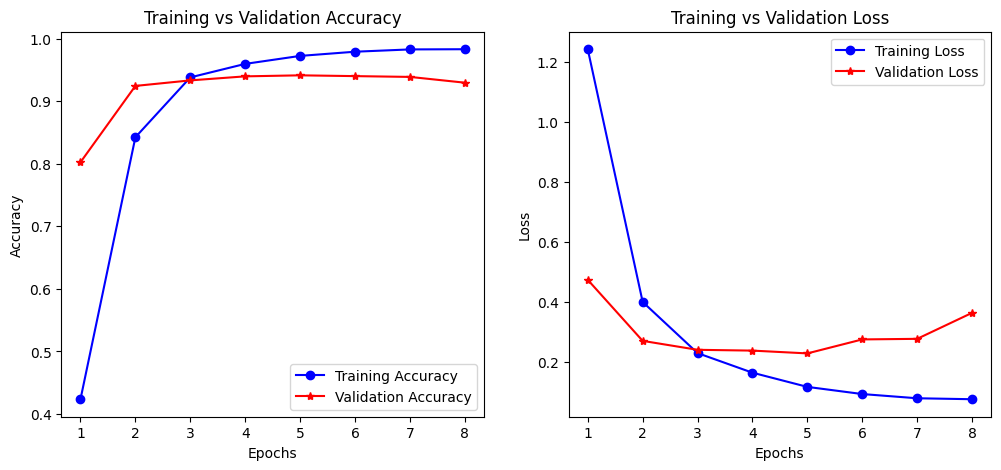

In [19]:
# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step
Classification Report:

                     precision    recall  f1-score   support

other_cyberbullying       0.87      0.89      0.88      1612
           religion       0.96      0.98      0.97      1566
                age       0.99      0.97      0.98      1603
             gender       0.90      0.89      0.90      1531
          ethnicity       0.99      0.96      0.97      1603

           accuracy                           0.94      7915
          macro avg       0.94      0.94      0.94      7915
       weighted avg       0.94      0.94      0.94      7915



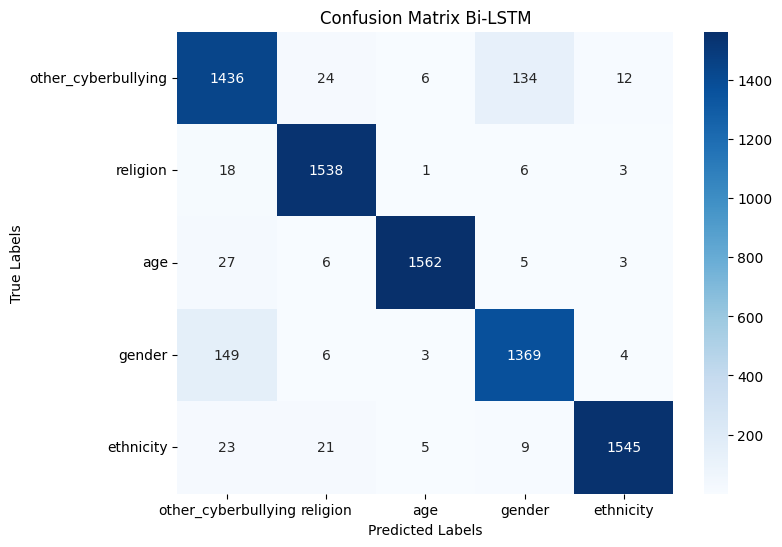

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Predict
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names (for reports)
class_names = ['other_cyberbullying', 'religion', 'age', 'gender', 'ethnicity']

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Bi-LSTM')
plt.show()